# FINAL PROJECT - Massive Perturber in a Mestel Disk

## IMPORT MODULES

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import constants as const
from astropy import units as u

from scipy.stats import norm
from scipy.stats import uniform
from scipy.special import gamma

from sklearn.mixture import GaussianMixture

## CHOOSE UNITS

In [2]:
# Chosen physical units (same name as in astropy https://docs.astropy.org/en/stable/units/#module-astropy.units.astrophys)
units = [100 * u.km, u.s, u.M_sun]
#["pc","year","M_sun"]

# Physical constants converted to chosen units
G = const.G.to(units[0]**3 / (units[1]**2 * units[2])).value
c = const.c.to(units[0] / units[1]).value
print(' --- PHYSICAL CONSTANTS ---')
print('\nG =', round(G), '\nc =', round(c))

# Conversion constants between physical and internal units
R0 = .01 * u.pc
R0 = R0.to(units[0]).value

M0 = 1500 # R0**3 / (G * T0**2)

T0 = np.sqrt(R0**3 / (G * M0)) # 1000

print('\n\n --- CONVERSION CONSTANTS ---')
print('\nR0 =', R0, '\nM0 =', M0, '\nT0 =', T0)

# Velocity
kms = u.km / u.second # km/s
vint = units[0] / units[1] # physical units (pc/ky)

 --- PHYSICAL CONSTANTS ---

G = 132712 
c = 2998


 --- CONVERSION CONSTANTS ---

R0 = 3085677581.4913673 
M0 = 1500 
T0 = 12148547925.443987


# 1 - INPUT

## SAMPLING

### Mestel disk

In [3]:
N = 5000

# Characteristic quantities of the system in physical units
R = 1 * u.pc
R = R.to(units[0]).value # disk radius

vc = 200 * kms
vc = vc.to(vint).value # circular velocity

sigma = 150 * kms
sigma = sigma.to(vint).value # velocity dispersion

M = R * vc**2 / G # total mass
S = vc**2 / (2 * np.pi * G * R) # surface density

# Masses - considering N p.cles of equal mass
m = M / N * np.ones(N)

print(' --- DISK PARAMETERS ---')
print('\n\t\t   units')
print('\t physical\t internal')
print('\nM\t', round(M), ' \t', round(M / M0))
print('R\t', round(R), '\t', round(R / R0))
print('vc\t', vc, '\t\t', round(vc / R0 * T0))
print('sigma\t', sigma, '\t\t', round(sigma / R0 * T0))

## --- TOOMRE STABILITY --- ##

Q = (2 * np.pi / 3.36) * sigma / vc
print('\nQ =', Q)

 --- DISK PARAMETERS ---

		   units
	 physical	 internal

M	 9300342  	 6200
R	 308567758149 	 100
vc	 2.0 		 8
sigma	 1.5 		 6

Q = 1.4024967203525862


In [4]:
## --- SAMPLE POSITION --- ##

rho = R * uniform.rvs(size=N)
phi = 2 * np.pi * uniform.rvs(size=N)

x = rho * np.cos(phi)
y = rho * np.sin(phi)
z = np.zeros(N)

In [30]:
print(rho.max() / R0, rho.min() / R0)
print(phi.max(), phi.min())
print(x.max(), x.min())
print(y.max() / R0, y.min() / R0)

98.45984630015106 1.105633523351779
6.102526336696058 0.08529466652703992
9.722337868333094e-10 3.240779289444365e-10
3.038050346483084e-19 9.238248678854968e-33


In [5]:
q = (vc / sigma)**2 - 1
F = 10**(-53) / (2 * np.pi**(3/2) * G * R)

def pvf(vf):
    return .75 * 10**1 * norm(0, sigma).pdf(vf) * (vf / vc)**q

In [6]:
# Azimuthal velocity sampling (could be implemented in a function)

n = N * 3
qs = np.linspace(0, 7, n)

gaus = norm(sigma, sigma) # chosen by eye
k = np.max(pvf(qs) / gaus.pdf(qs)) # 'normalization' constant of the gaussian

qs = gaus.rvs(size=n)
us = uniform.rvs(size=n)

mask = pvf(qs[qs >= 0]) / (k * gaus.pdf(qs[qs >= 0])) > us[qs >= 0]
vf = qs[qs >= 0][mask][:N] # azimuthal velocity
print('Accepted values: ', qs[qs >= 0][mask].shape)

Accepted values:  (9545,)


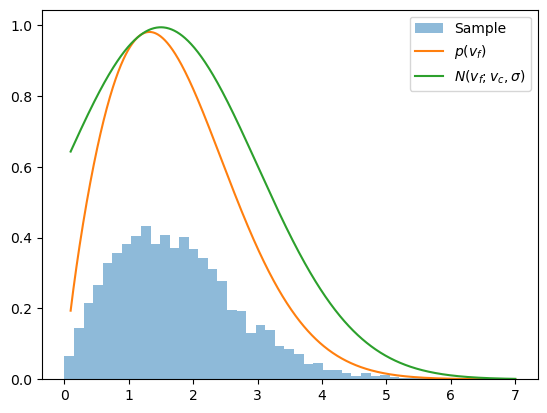

In [41]:
## --- PLOT --- ##

plt.hist(vf, bins='fd', density=True, alpha=.5, label='Sample')

v = np.linspace(0.1, 7, 1000)

aa = pvf(v)
plt.plot(v, aa, label=r'$p(v_f)$')

bb = norm(sigma, sigma).pdf(v)
k = np.max(aa / bb)
plt.plot(v, k * bb, label=r'$N(v_f; v_c, \sigma)$')

# Gaussian mixture (with one component) fit
model = GaussianMixture(1)
#model.fit(vf[:, None])

#cc = np.exp(model.score_samples(v[:, None]))
#mean = model.means_[0,0]
#std = model.covariances_[0,0,0]
#plt.plot(v, cc, '--', label=r'$N(v_f; $'+f'{mean:.2f}, {std:.2f})')

plt.legend();

In [7]:
## --- SAMPLE VELOCITY --- ##

vr = norm(0, sigma).rvs(size=N) # radial velocity

vx = vr * np.cos(phi) - vf * np.sin(phi)
vy = vr * np.sin(phi) + vf * np.cos(phi)
vz = np.zeros(N)

In [26]:
print(vf.max() / R0 * T0, vf.min() / R0 * T0, vf.mean() / R0 * T0)
print(vr.max() / R0 * T0, vr.min() / R0 * T0, vr.mean() / R0 * T0)

print(vx.max() / R0 * T0, vx.min() / R0 * T0, vx.mean() / R0 * T0)
print(vy.max() / R0 * T0, vy.min() / R0 * T0, vy.mean() / R0 * T0)

9.050831056035443 6.146889624449564 7.617071825901067
1.9778911717295498 -1.8809368085830065 -0.031007974456974237
8.048733144698572 -7.550920579232045 0.3737632228635824
9.05953005720735 -7.983725994425215 0.3548077595952188


In [19]:
print(m[0] / M0)

1.240045552721907


### Massive perturber

In [10]:
Lambda = 100
R_per = 2 * R / 3

M_per = M / Lambda

# Set the position
x_per = R_per
y_per = 0
z_per = 0

# Set the circular velocity
vx_per = 0
vy_per = vc
vz_per = 0

In [10]:
# ADD PERTURBER TO THE SYSTEM
N += 1

m = np.hstack((m, M_per))

x, y, z = np.hstack((x, x_per)), np.hstack((y, y_per)), np.hstack((z, z_per))

vx, vy, vz = np.hstack((vx, vx_per)), np.hstack((vy, vy_per)), np.hstack((vz, vz_per))

## PRINT INPUT FILE

In [8]:
# FOR TREECODE

file_in = 'IFFP-2.txt'

m = m / M0

x = x / R0
y = y / R0
z = z / R0

vx = vx / R0 * T0
vy = vy / R0 * T0
vz = vz / R0 * T0

n_dim = 3 # NOTE: can it be done just in 2D ?
time_in = 0 # initial time

out_r = np.column_stack((x, y, z))
out_v = np.column_stack((vx, vy, vz))
with open(file_in, 'w') as file:
    file.write(f'{N}\n')
    file.write(f'{n_dim}\n')
    file.write(f'{time_in}\n')
    for i in m:
        file.write(f'{i}\n')
    np.savetxt(file, out_r)
    np.savetxt(file, out_v)

## INTEGRATION PARAMETERS

In [11]:
# INTEGRATION PARAMETERS (for treecode)
# NOTE: parameters must be converted in internal units

alpha = .05

print(' --- INTEGRATION PARAMETERS ---')
print('\nAll values in internal units')

# Orbital period of the perturber
T_orb = 2 * np.pi * R / vc
print('\nT_orb =', round(T_orb / T0, 2))

# Dynamical friction timescale (to be adjusted for circular case)
#T_frc = 1.17 * (a * R_per)**2 * vy_per / (np.log(Lambda) * G * M_per)


# Smoothing length
R_i = G * M_per / sigma**2
eps_min = R / N # from m * R / M, such that M_eps > m
print('\nLimits on epsilon:', round(eps_min / R0, 2), '< eps <', round(R_i / R0, 2))

eps = 10**(-2) * u.pc
eps = eps.to(units[0]).value

M_eps = M * eps / R
print('eps =', round(eps / R0, 3), ' M_eps =', round(M_eps / M0, 2))

t_eps = 2 * np.pi * eps**(3/2) / np.sqrt(G * m[0])
print('t_eps =', round(t_eps / T0, 2), 'if m > M_eps')
t_eps = eps / vc # if lower limit on eps is satisfied
print('t_eps =', round(t_eps / T0, 5), 'if m < M_eps') 

print('\nConversion constants: R0 =', R0, 'T0 =', T0, 'M0 =', M0)

 --- INTEGRATION PARAMETERS ---

All values in internal units

T_orb = 79.8

Limits on epsilon: 0.02 < eps < 1.78
eps = 1.0  M_eps = 62.0
t_eps = 218.53 if m > M_eps
t_eps = 0.127 if m < M_eps

Conversion constants: R0 = 3085677581.4913673 T0 = 12148547925.443987 M0 = 1500


# 2 - ANALYSIS

OFFP-1-1.txt: Mestel disk with integration parameters {dtime=0.05 eps=1 theta=0.1 tstop=200 dtout=1}\
OFFP-1-2.txt: Mestel disk with integration parameters {dtime=0.01 eps=1 theta=0.1 tstop=100 dtout=1}\
The disk spread out and fragmentate, indeed Q < 1.

OFFP-2-1.txt: Mestel disk with $v_c$ and $\sigma$ giving Q > 1. Integration parameters are {dtime=0.05 eps=1 theta=0.1 tstop=100 dtout=1}

In [14]:
# Reading file

file_out = 'OFFP-2-1.txt'

N = 5000
n = 3 * N + 3 # 'block' length
m = 3     # number of rows to skip (i.e. lines containing n. bodies and time)

time_rows = []
m_rows, r_rows, v_rows = [], [], []
with open(file_out, "r") as file:
    lines = file.readlines()
    for i in range(0, len(lines), n):  # move through rows every n rows
        time_rows.extend(lines[i+2:i+m])
        m_rows.extend(lines[i+m:i+N+3])
        r_rows.extend(lines[i+N+3:i+2*N+3])
        v_rows.extend(lines[i+2*N+3:i+n])

time = np.loadtxt(time_rows)

In [15]:
# FETCHING DATA

m = np.loadtxt(m_rows) # masses
m = np.tile(m, 3).reshape((time.size, N, 3)).transpose((1, 0, 2))

r = np.loadtxt(r_rows) # positions
r = r.reshape((time.size, N, 3))#.transpose((1, 0, 2))
d = np.linalg.norm(r, axis=2) # distance from center

v = np.loadtxt(v_rows) # velocities
v = v.reshape((time.size, N, 3)).transpose((1, 0, 2))
vm = np.linalg.norm(v, axis=2)

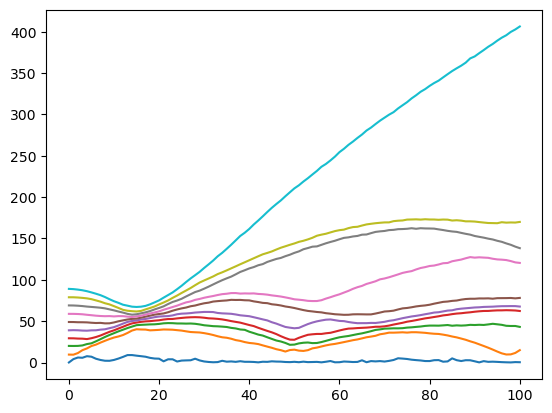

In [12]:
#plt.plot(time, d[:, ::100])

d_sort = np.sort(d, axis=1)
plt.plot(time, d_sort[:, ::500]);

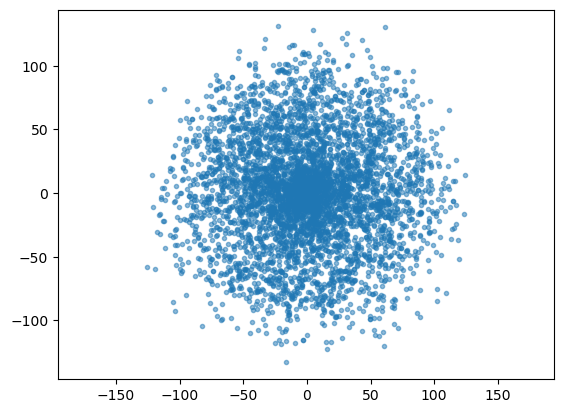

In [20]:
plt.scatter(r[3, :, 0], r[3, :, 1], marker='.', alpha=.5)
#plt.scatter(r[9, :, 0], r[9, :, 1], marker='.', alpha=.5)
#plt.scatter(r[0, :, 0], r[0, :, 1], marker='.', alpha=.5)

plt.axis('equal');

In [ ]:
# Calcolare la densità e colorare il plot in funzione della densità così da capire come evolve nel tempo e se è legata allo spread del disco

# Possibile effetto di bordo dovuto al troncamento del raggio -> controllare con più particelle e raggio più grande se cambia qualcosa

# Opzione 1: massa al centro per fare potenziale sferico così da avere disco stabile
# Opzione 2: trovare disco che con qualche approssimazione sulla DF mi è stabile